In [1]:
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft
from IPython.display import Latex
import scipy.signal

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom12_ics_v1/output', 247, basename='snap')
# snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output',
#                    305, basename='snapshot')
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom8/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([5e2, 5e2, 5e2], dtype=float) ## good for testing
# widths = np.array([2e1, 2e1, 2e1], dtype=float)

# test_types = ['diff_of_gaussians','direct_mexican']
# test_type = 



The default number of OpenMP threads, 8, exceeds the 1 available on your system. Setting numthreads=1. You can set numthreads with e.g. the command
 paicos.set_numthreads(16)




In [2]:
get_index_cube = pa.util.get_index_of_cubic_region

import cmasher as cmr
get_ipython().run_line_magic('matplotlib', 'widget')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

grays = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))
blues = plt.cm.Blues_r(np.linspace(0,1,10))
greens = plt.cm.Greens_r(np.linspace(0,1,10))
oranges = plt.cm.Oranges_r(np.linspace(0,1,10))

# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 16
plt.rcParams['ytick.labelsize']= 16
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'


In [3]:

def enforce_hermitian(amplitude_matrix):
    ## this is for odd matrices
    amplitudes = amplitude_matrix.copy()
    Nx, Ny, Nz = amplitudes.shape
    for kk in range(0,Nz//2):
        amplitudes[:,:,kk]=np.conj(np.flip(amplitudes)[:,:,kk])
    
    amplitudes[:Nx//2+1,:Ny//2+1,Nz//2]=np.conj(np.flip(amplitudes)[:Nx//2+1,:Ny//2+1,Nz//2])
    amplitudes[:Nx//2+1,Ny//2+1:,Nz//2]=np.conj(np.flip(amplitudes)[:Nx//2+1,Ny//2+1:,Nz//2])
    amplitudes[Nx//2+1:,Ny//2+1:,Nz//2]=np.conj(np.flip(amplitudes)[Nx//2+1:,Ny//2+1:,Nz//2])
    amplitudes[Nx//2+1:,:Ny//2+1,Nz//2]=np.conj(np.flip(amplitudes)[Nx//2+1:,:Ny//2+1,Nz//2])

    return amplitudes

In [4]:
def P1d(FFTw, K2, widths):

    # FFTw and K2 have the same shape:
    # (Nx,Ny,Nz) (for complex transform)

    Nx, Ny, Nz = FFTw.shape
    Lx, Ly, Lz = widths

    kxmax = (2.0*np.pi/Lx)*(Nx//2)
    kymax = (2.0*np.pi/Ly)*(Ny//2)
    kzmax = (2.0*np.pi/Lz)*(Nz//2)


    kmax = np.sqrt(kxmax**2 + kymax**2 + kzmax**2)
    kmin = 0
    nbin = int(kmax/(2.0*np.pi/np.min(widths) ) + 0.5)
    deltak = 2.0*np.pi/np.min(widths)

    spectrum_1d = np.zeros(nbin)
    wavevec = np.arange(nbin)*deltak

    for i in range(Nx):
        for j in range(Ny):
            for k in range(Nz):

                m = int( np.floor( pow( K2[i,j,k], 0.5 ) / (deltak) + 0.5 ) )
                if (m < nbin):
                    spectrum_1d[m] += np.real( FFTw[ i,j,k] * np.conj( FFTw[i,j,k] ) ) / (Nx*Ny*Nz)**2

    spectrum_1d *= (2.*np.pi/deltak)*(Lx*Ly*Lz)

    energy_fourier_space = np.sum(spectrum_1d*deltak/(2.0*np.pi))
    print('energy (fourier space) = %.4e'%(energy_fourier_space))
    return spectrum_1d, wavevec

In [5]:
# cp.cuda.Device(3).use()
# with cp.cuda.Device(3):

# Gauss = snap.uq('G')
arepo_length = snap['0_Coordinates'].uq
density_unit = snap['0_Density'].uq
kpc = snap.uq('kpc')

weight = None

filter_length_max = (widths[0]/10)*np.ones(snap['0_Diameters'].shape)*arepo_length


Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [6]:
# epsilon = 1e-3
# def extract_turbulent_scalar(snap, sf, variable, filter_length, weight, test_type=None, 
#                              filter_type="mexican-hat", 
#                              iterative=False, optimized=True):

#     if (filter_type=="mexican-hat"):
#         print("With mexican-hat the first object returned is the narrow-pass variable, the second object is the remaining.")
        
#         if (test_type=="direct_mexican"): 
#             filt_var = mhat.filter_variable(variable, filter_length, weight=weight, 
#                                           filter_type="mexican-hat", iterative=iterative, optimized=optimized)
        
#         elif (test_type=="diff_of_gaussians"): 
#             filt_var_1 = mhat.filter_variable(variable, filter_length/np.sqrt(1.0+epsilon), weight=weight, 
#                                               filter_type="gaussian", iterative=iterative, optimized=True)
#             filt_var_2 = mhat.filter_variable(variable, filter_length*np.sqrt(1.0+epsilon), weight=weight, 
#                                               filter_type="gaussian", iterative=iterative, optimized=True)
#             filt_var = (filt_var_1 - filt_var_2)/epsilon

#     else:
#         filt_var = mhat.filter_variable(variable, filter_length, weight=weight, 
#                                           filter_type=filter_type, iterative=iterative, 
#                                       optimized=optimized)

#     print("min/max/avg occupancy cartesian tiling %d / %d / %.2f"%(mhat.tile.particles_per_tile.min(),
#                                                                     mhat.tile.particles_per_tile.max(),
#                                                                     cp.mean(mhat.tile.particles_per_tile)))
#     if isinstance(variable, str):
#         variable = snap[variable]

        
#     smoothVar = np.zeros_like(variable)
#     turbVar = np.zeros_like(variable)
    
#     smoothVar[mhat.index] = filt_var
#     turbVar[mhat.index] = variable[mhat.index] - filt_var

#     return smoothVar, turbVar


# def volume_integral(snap, sf, qt, indices):
#     if isinstance(qt, str):
#         qt = snap[qt]
        
#     a = np.sum((qt*snap['0_Volume'])[indices])
#     # vol = np.sum((snap['0_Volume'])[mhat.indicesFirstPass])
#     # a = np.sum((qt*snap['0_Volume'])[mhat.index])
#     # vol = np.sum((snap['0_Volume'])[mhat.index])
#     return a

In [7]:
# nondimensional_unit = snap['0_Density'][0]/snap['0_Density'][0]

In [8]:
# class MexicanHatPowerSpectrum(tc.SmoothingFilter):
#     def compute_spectrum(self, variable, mask=None, weight=None, optimized=False):

#         if isinstance(variable, str):
#             var_unit = snap[variable].uq
#         else:
#             var_unit = variable.uq
        

#         self.kmin = np.sqrt(2.0)/(self.max_search_radius.value/4.1)
#         self.kmax = 20.*self.kmin
#         k_vec = np.logspace(np.log10(self.kmin), np.log10(self.kmax), 12) 
#         power_spectrum = np.zeros(k_vec.shape)

#         for i in range(len(k_vec)):
#             k = k_vec[i]
#             filt_len = (np.sqrt(2.0)/k)*np.ones(snap[variable].shape)*arepo_length

#             if (mask is None):
#                 var_filtered, _ = extract_turbulent_scalar(snap, self, 
#                                                           variable, 4.*filt_len, 
#                                                           weight, test_type="diff_of_gaussians",
#                                                            iterative=False)
                
#                 var_variance = volume_integral(snap, self, var_filtered**2,
#                                               self.indicesFirstPass)
#             else:
#                 ## equation A9 Arevalo+2012
#                 G_sigma1_var, _ = extract_turbulent_scalar(snap, self, 
#                                                           variable, 4.*filt_len/np.sqrt(1.0+epsilon), 
#                                                           weight, filter_type="gaussian",
#                                                            iterative=False)
#                 # note that it does not matter what unit is mask
#                 # because in the end it cancels out
#                 # but we need a unit for the following function to work

#                 # we use the convention that mask=1=True on the cells which we want
#                 # to include, and mask=0=False on the cells to exclude
#                 G_sigma1_mask, _ = extract_turbulent_scalar(snap, self, 
#                                                           mask*var_unit, 4.*filt_len/np.sqrt(1.0+epsilon), 
#                                                           weight, filter_type="gaussian",
#                                                            iterative=False)

#                 G_sigma2_var, _ = extract_turbulent_scalar(snap, self, 
#                                                           variable, 4.*filt_len*np.sqrt(1.0+epsilon), 
#                                                           weight, filter_type="gaussian",
#                                                            iterative=False)
#                 G_sigma2_mask, _ = extract_turbulent_scalar(snap, self, 
#                                                           mask*var_unit, 4.*filt_len*np.sqrt(1.0+epsilon), 
#                                                           weight, filter_type="gaussian",
#                                                            iterative=False)

#                 S_k = (G_sigma1_var / G_sigma1_mask - G_sigma2_var / G_sigma2_mask ) * mask * var_unit

#                 ## this is necessary to get rid of the NaNs
#                 ## due to division by G_sigma1/2_mask 
#                 ## (which is zero on a subset of the masked cells)
#                 S_k[~mask] = 0.0
                
#                 S_k /= epsilon

#                 vol_tot = volume_integral(snap, self, np.ones(mask.shape),
#                                               self.indicesFirstPass)

#                 vol_non_masked = volume_integral(snap, self, mask,
#                                               self.indicesFirstPass)

#                 # equation A10 of Arevalo+2012
#                 var_variance = (vol_tot/vol_non_masked) * volume_integral(snap, self, 
#                                                                           S_k**2,
#                                                                           self.indicesFirstPass)
#             # equation A11 of Arevalo+2012 replacing k_r -> k / (2 \pi) 

#             ## this is the 3D energy spectral density
#             power_spectrum[i] = (var_variance.value/k**3)*(np.pi**(3./2.)*2**(11./2.))/(3.*5./2.)

#             ## for 1D energy spectral density
#             ## (we are assuming S_3D does not depend on the angular variable)
#             power_spectrum[i] *= 4.0*np.pi*(k/(2.*np.pi))**2
            
        
#         return k_vec, power_spectrum

In [9]:

mhat = tc.MexicanHatPowerSpectrum(snap, center, widths, npix=256, orientation=None, 
                        search_radius=filter_length_max.value)

In [10]:
# volume_integral(snap, sf, snap['0_synthetic_rhofield']**2)

In [11]:
# indices_plus_layer = pa.util.get_index_of_cubic_region_plus_thin_layer(snap['0_Coordinates'], 
#                                                                   center, widths*arepo_length, 
#                                                                   snap['0_Diameters'].value*arepo_length,
#                                                                   snap.box )

In [12]:
# indices_no_layer = pa.util.get_index_of_cubic_region(snap['0_Coordinates'], 
#                                                                   center, widths*arepo_length, 
#                                                                   snap.box )

In [13]:
# np.sum(indices_no_layer), np.sum(indices_plus_layer)

In [14]:
## generate Kolmogorov IC
nmax = 129
nfreq_tot = nmax**3
rng = np.random.default_rng(seed=456789)

x = snap['0_Coordinates'][mhat.index][:, 0].value - center[0].value
y = snap['0_Coordinates'][mhat.index][:, 1].value - center[1].value
z = snap['0_Coordinates'][mhat.index][:, 2].value - center[2].value

kx_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[0])
ky_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[1])
kz_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[2])

KX, KY, KZ = np.meshgrid(kx_vec, ky_vec, kz_vec, sparse=False, indexing='ij')

K2 = KX**2 + KY**2 + KZ**2 
phases_rho = 2.0*np.pi*rng.uniform(low=-1.0, high=1.0, size=(nmax,nmax,nmax))

K2min = (2.0*np.pi/widths[0])**2 + (2.0*np.pi/widths[1])**2 + (2.0*np.pi/widths[2])**2
# K2min *=9
power_law_exponent = -5./3.
# energy per 3D mode \times k^2 = E(k) \sim k^power_law_exponent
# ==> energy per 3D mode \sim k^[(power_law_exponent-2)/2]
ampl = np.zeros(K2.shape)
ampl = np.where(K2>0,np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
# ampl = np.where(K2==0,10.0,ampl)

amplitudes_rho = nfreq_tot*ampl*np.exp(1j*phases_rho)     
amplitudes_rho = enforce_hermitian(amplitudes_rho)

synthetic_rhofield = np.zeros(snap['0_Density'].shape)
## redo this with finufft 
synthetic_rhofield[mhat.index] = np.real(finufft.nufft3d2(((2.0*np.pi/widths[0])*x)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[1])*y)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[2])*z)%(2.*np.pi), 
                             amplitudes_rho/(nfreq_tot)   , eps=1e-10, isign=-1))
# synthetic_rhofield[mhat.index] = np.real(finufft.nufft3d2(((2.0*np.pi/widths[0])*x), 
#                                                         ((2.0*np.pi/widths[1])*y), 
#                                                         ((2.0*np.pi/widths[2])*z), 
#                              amplitudes_rho, eps=1e-10, isign=-1))

snap['0_synthetic_rhofield'] = synthetic_rhofield * density_unit

/tmp/ipykernel_90475/1806230127.py:25: RuntimeWarning: divide by zero encountered in power
  ampl = np.where(K2>0,np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)


In [15]:


# k_vec, power_spectrum = mhat.compute_spectrum('0_synthetic_rhofield', mask=None, 
#                                              weight=None, optimized=False)

# let's apply a mask that zeroes out the central sphere of radius 1e2
mask = ~pa.util.get_index_of_radial_range(snap['0_Coordinates'], center, 0.0, 1e2)
power_spectrum, k_vec = mhat.compute_spectrum('0_synthetic_rhofield', 
                                              mask=mask, 
                                             weight=None, optimized=False)

min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18


/home/lperrone/miniforge3/envs/paicos-conda/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18


/home/lperrone/miniforge3/envs/paicos-conda/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/lperrone/miniforge3/envs/paicos-conda/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in subtract
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/lperrone/miniforge3/envs/paicos-conda/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg occupancy cartesian tiling 0 / 5 / 0.18
min/max/avg 

In [ ]:
# mhat.filter_variable('0_synthetic_rhofield', 10.*arepo_length, weight=None, 
#                     optimized=False, filter_type="gaussian", iterative=False)

## The problem here is that the contribution of the thin layer ~hsml around the 
cube is actually very large. For this reason, computing the total mass (or energy) with 
the volume_integral and with the cartesian deposited qty does not lead to the same result.

In [ ]:
# volume_integral(snap, mhat, snap['0_synthetic_rhofield'], 
#                 indices_no_layer).value

In [ ]:
# volume_integral(snap, mhat, snap['0_synthetic_rhofield'], 
#                 indices_plus_layer).value

In [ ]:
# thin_shell = np.logical_and(indices_plus_layer, np.logical_not(indices_no_layer))

In [ ]:
# np.sum(thin_shell), np.sum(indices_plus_layer), np.sum(indices_no_layer)

In [ ]:
# volume_integral(snap, mhat, snap['0_synthetic_rhofield'], 
#                 thin_shell).value

In [16]:
npoints = 128
depo = tc.DepositCartesianGrid(snap, center, widths, npoints=npoints, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type="TSC")

## deposit density to cartesian grid
density_cartesian = depo.deposit_variable('0_synthetic_rhofield', weight='0_Volume')

# basic 
powerspectr_depo, k1d_depo, _ = depo.power_spectrum1d(density_cartesian)


energy (real space) = 1.7362e+10
energy (fourier space) = 1.7362e+10


In [ ]:
# np.min(snap['0_Coordinates'][depo.index][:,0]-center[0])

## WIth kernel_type='NGP' the cell below gives the same result as the volume_integral 
over indices_no_layer. WIth higher-order interpolation this is not true anymore, as 
contribution from nearby cells are now included

In [ ]:

# voxel = float(depo.tile_widths[0]*depo.tile_widths[1]*depo.tile_widths[2])*snap['0_Volume'].unit
# np.sum(density_cartesian*voxel).value

In [ ]:
# np.sum(density_cartesian**2*voxel).value

In [ ]:
# volume_integral(snap, mhat, snap['0_synthetic_rhofield']**2, 
#                 indices_no_layer).value

In [18]:
powerspectrrho, k1d = P1d(amplitudes_rho, K2, widths) 

energy (fourier space) = 2.0361e+10


Text(0.5, 1.0, 'Energy Spectral Density')

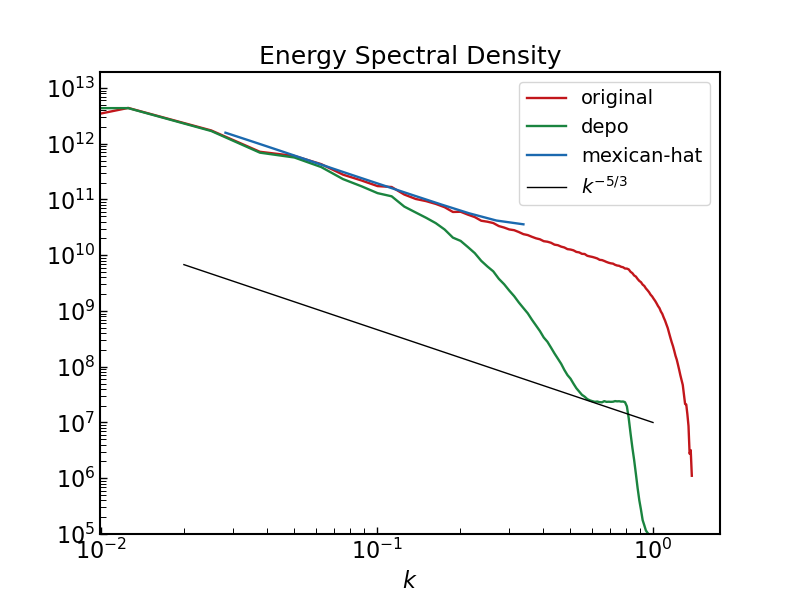

In [19]:
fig, ax = plt.subplots(figsize=(8,6))

tt = np.logspace(np.log10(2e-2), 0, 100)

# powerspectr_orig, k1d_orig = spectra_var_orig

# ax.plot(k1d_orig.value, powerspectr_orig.value, ls='-', color=grays[6],
#             markerfacecolor='none', label=r'original')

ax.plot(k1d, powerspectrrho, ls='-', color=reds[2],
        markerfacecolor='none', label=r'original')

ax.plot(k1d_depo, powerspectr_depo, ls='-', color=greens[2],
        markerfacecolor='none', label=r'depo')

# ax.plot(k_vec, (1./np.pi)*power_spectrum*k_vec**2, ls='-', color=blues[2],
        # markerfacecolor='none', label=r'mexican-hat')
ax.plot(k_vec, power_spectrum, ls='-', color=blues[2],
        markerfacecolor='none', label=r'mexican-hat')

ax.plot(tt, 1e7*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')

ax.set_xlabel('$k$', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(ymin=1e5)

ax.legend(loc='best',ncols=1,fontsize=14)

ax.set_title(r'Energy Spectral Density', fontsize=18)

# ax.set_xlim(xmin=1e-2)
# ax.set_ylim(ymin=1e-25,ymax=1e-11)
# ax.set_ylim(ymin=1e-20)
# ax[1].set_xlim(xmax=30)
# savename = "power_spectrum_%s-%s"%(filter_type, var_type)

# plt.savefig('./../../plots/power-spectra/mexican-hat-spectrum-synthetic.pdf',dpi=400)
